# Forecasting Brent Crude Oil Prices Using ARIMA Models
## TSAC Individual Project — 2024/2025

### Abstract
This project analyzes monthly Brent Crude Oil prices from May 1987 to December 2023 
(n=440 observations) sourced from the Federal Reserve Economic Data (FRED) database. 
After confirming non-stationarity via the Augmented Dickey-Fuller test, first-differencing 
was applied to achieve stationarity. ACF/PACF analysis guided the identification of 
candidate ARIMA models. The final model, ARIMA(2,1,1), was selected based on the lowest 
AIC (2622.74). Residual diagnostics confirmed the absence of autocorrelation (Ljung-Box 
p > 0.05), though heavy tails were noted. A 12-month out-of-sample forecast yielded a 
MAPE of 7.15%, demonstrating reasonable predictive accuracy for a volatile commodity series.

## 1. Introduction
Brent Crude Oil is the world's leading benchmark for oil prices, used to price 
approximately two-thirds of globally traded crude oil supplies. Its price is influenced 
by a complex mix of geopolitical events, OPEC production decisions, global demand cycles, 
and macroeconomic conditions. Understanding and forecasting oil price movements is of 
critical importance to governments, energy companies, investors, and policymakers alike.

This project investigates whether historical patterns in monthly Brent Crude Oil prices 
can be used to produce reliable short-term forecasts. The data spans nearly four decades 
(1987–2023), covering major market events including the 2008 financial crisis, the 2014–2016 
oil glut, and the COVID-19 demand collapse in 2020. A time series approach based on the 
Box-Jenkins ARIMA methodology is used throughout the analysis.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

In [7]:

# Load data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU"
df = pd.read_csv(url, parse_dates=["observation_date"], index_col="observation_date")
df.columns = ["price"]
df = df[df["price"] != "."].astype(float)


In [8]:
# Resample to monthly frequency
df = df.resample("ME").mean().dropna()
print(f"Dataset shape: {df.shape}")
df.tail()

Dataset shape: (467, 1)


,price
observation_date,
2025-11-30,63.797000
2025-12-31,62.544286
2026-01-31,66.602381
2026-02-28,70.887000
2026-03-31,97.998125


Total: 452 | Train: 440 | Test (withheld): 12


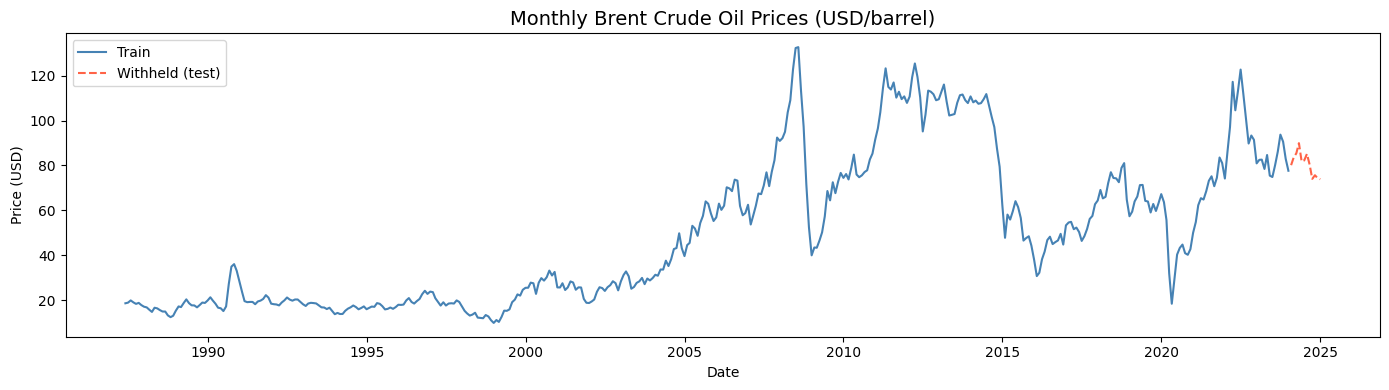

In [9]:
# Keep data up to clean cutoff, withhold last 12 months for forecasting
df = df[:"2024-12"]
train = df[:-12]
test  = df[-12:]

print(f"Total: {len(df)} | Train: {len(train)} | Test (withheld): {len(test)}")

# Plot the full series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train["price"], label="Train", color="steelblue")
ax.plot(test.index,  test["price"],  label="Withheld (test)", color="tomato", linestyle="--")
ax.set_title("Monthly Brent Crude Oil Prices (USD/barrel)", fontsize=14)
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("ts_plot.png", dpi=150)
plt.show()

## 2. Model Specification

### 2.1 Stationarity Analysis
The first step in the Box-Jenkins methodology is to assess whether the series is stationary. 
Visual inspection of the time series reveals a clear long-term upward trend and changing 
variance over time, both signs of non-stationarity. This was confirmed formally using the 
Augmented Dickey-Fuller (ADF) test.

=== ADF Test: Original Series ===
ADF Statistic : -1.7791
p-value       : 0.3909
=> Non-stationary

=== ADF Test: First-Differenced Series ===
ADF Statistic : -9.6693
p-value       : 0.0000
=> Stationary ✅


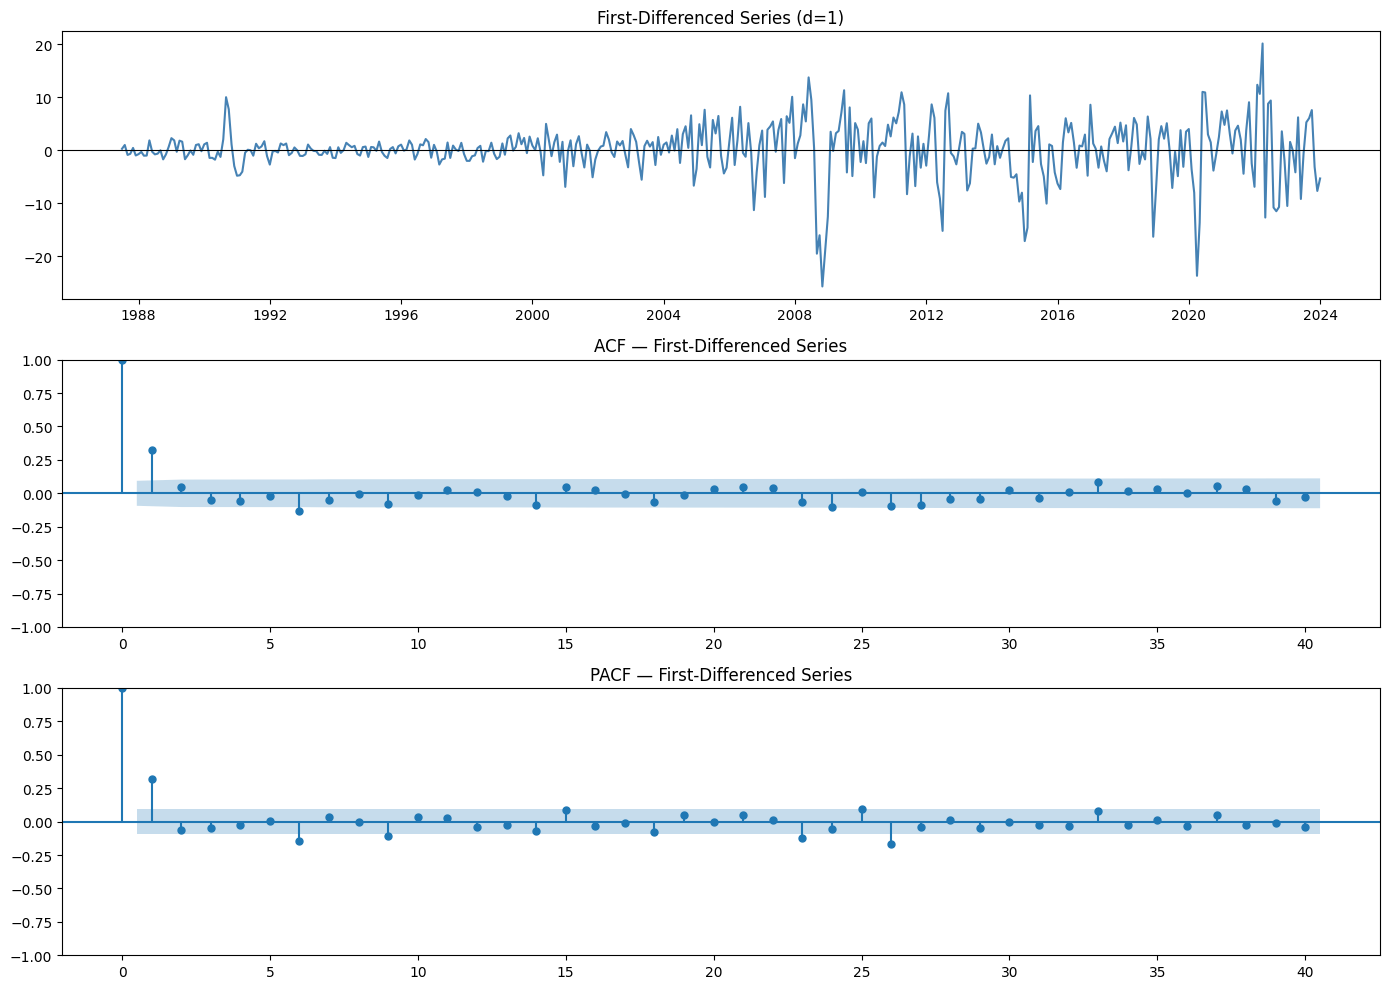

In [10]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF Test on original series
result = adfuller(train["price"].dropna())
print("=== ADF Test: Original Series ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print("=> Non-stationary" if result[1] > 0.05 else "=> Stationary")

# First difference
train_diff = train["price"].diff().dropna()

result2 = adfuller(train_diff)
print("\n=== ADF Test: First-Differenced Series ===")
print(f"ADF Statistic : {result2[0]:.4f}")
print(f"p-value       : {result2[1]:.4f}")
print("=> Non-stationary" if result2[1] > 0.05 else "=> Stationary ✅")

# Plot differenced series + ACF/PACF
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(train_diff.index, train_diff, color="steelblue")
axes[0].set_title("First-Differenced Series (d=1)")
axes[0].axhline(0, color="black", linewidth=0.8)

plot_acf(train_diff,  lags=40, ax=axes[1], title="ACF — First-Differenced Series")
plot_pacf(train_diff, lags=40, ax=axes[2], title="PACF — First-Differenced Series")

plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=150)
plt.show()

### 2.2 Stationarity Results
The ADF test on the original series yielded a p-value of 0.39, confirming non-stationarity. 
After applying first-order differencing (d=1), the ADF statistic dropped to -9.67 with 
p≈0.000, establishing stationarity. Therefore **d = 1** is selected.

### 2.3 ACF/PACF Analysis
The ACF of the differenced series shows a significant spike at lag 1 followed by rapid 
decay, suggesting an MA(1) component (q=1). The PACF similarly cuts off after lag 1–2, 
suggesting an AR(1) or AR(2) component. Based on this, the following candidate models 
were considered: ARIMA(0,1,1), ARIMA(1,1,0), ARIMA(1,1,1), ARIMA(2,1,1), and ARIMA(1,1,2).

### 2.4 Model Selection via AIC/BIC

In [11]:
from statsmodels.tsa.arima.model import ARIMA

# Fit all candidate models and compare AIC/BIC
candidates = [(0,1,1), (1,1,0), (1,1,1), (2,1,1), (1,1,2)]
results_table = []

for order in candidates:
    try:
        m = ARIMA(train["price"], order=order).fit()
        results_table.append({"Order": str(order), "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)})
    except:
        pass

results_df = pd.DataFrame(results_table).sort_values("AIC")
print(results_df.to_string(index=False))

# Fit the best model
best_order = eval(results_df.iloc[0]["Order"])
model = ARIMA(train["price"], order=best_order).fit()
print(f"\nBest model: ARIMA{best_order}")
print(model.summary())

    Order     AIC     BIC
(2, 1, 1) 2622.74 2639.08
(1, 1, 0) 2625.34 2633.51
(0, 1, 1) 2626.08 2634.25
(1, 1, 1) 2626.13 2638.39
(1, 1, 2) 2627.69 2644.03

Best model: ARIMA(2, 1, 1)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  440
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1307.372
Date:                Sun, 29 Mar 2026   AIC                           2622.744
Time:                        13:40:49   BIC                           2639.082
Sample:                    05-31-1987   HQIC                          2629.190
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2669     

### 2.5 Selected Model
| Model | AIC | BIC |
|-------|-----|-----|
| ARIMA(2,1,1) | 2622.74 | 2639.08 |
| ARIMA(1,1,0) | 2625.34 | 2633.51 |
| ARIMA(0,1,1) | 2626.08 | 2634.25 |
| ARIMA(1,1,1) | 2626.13 | 2638.39 |
| ARIMA(1,1,2) | 2627.69 | 2644.03 |

**ARIMA(2,1,1)** achieved the lowest AIC (2622.74) and was selected as the final model. 
All estimated coefficients (ar.L1, ar.L2, ma.L1) are statistically significant (p < 0.001), 
confirming the validity of the chosen order.

## 3. Fitting and Diagnostics
The ARIMA(2,1,1) model was fitted on 440 training observations. Residual diagnostics 
are performed below to validate model adequacy.

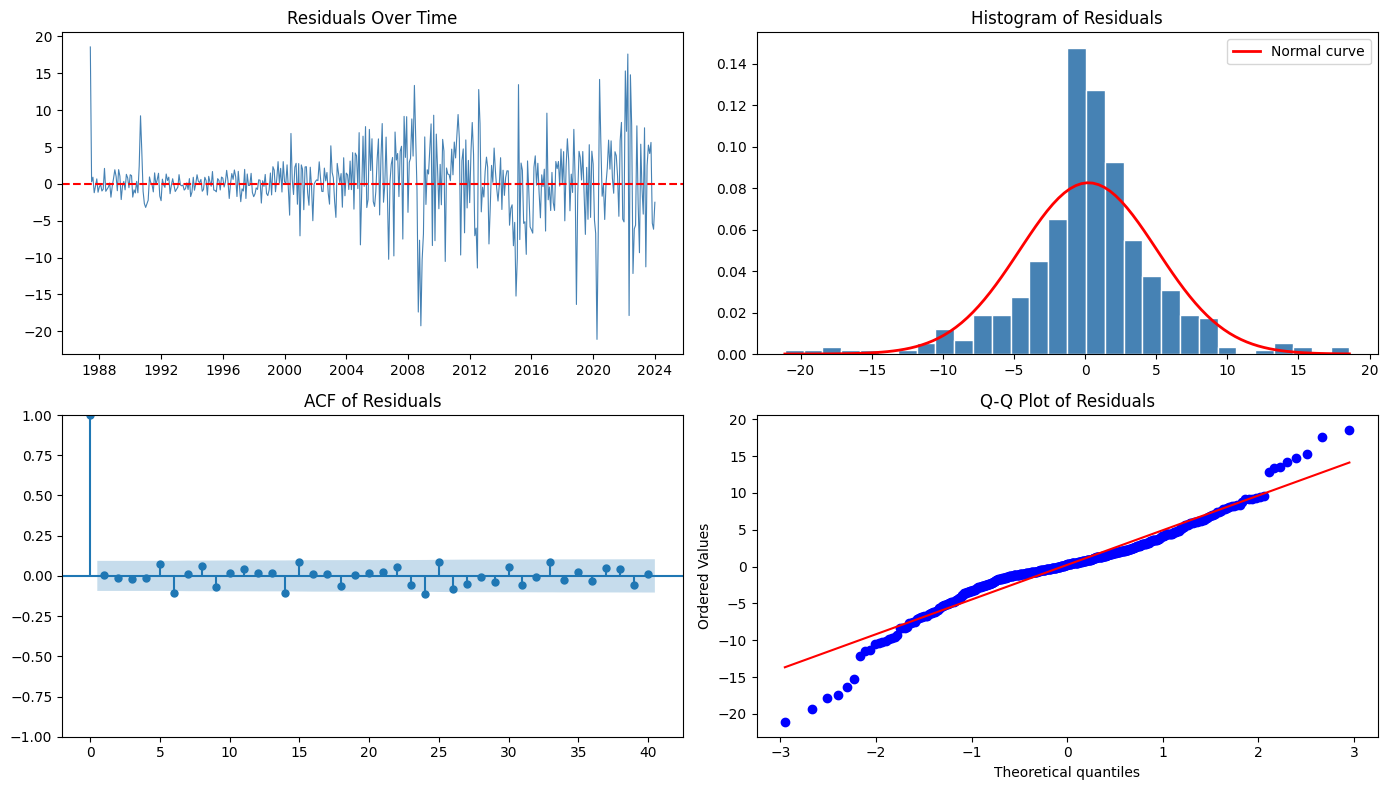


=== Ljung-Box Test ===
      lb_stat  lb_pvalue
10  12.250771   0.268624
20  24.423738   0.224372

=> No autocorrelation in residuals


In [12]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Residual diagnostics
residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Residuals over time
axes[0,0].plot(residuals, color="steelblue", linewidth=0.8)
axes[0,0].axhline(0, color="red", linestyle="--")
axes[0,0].set_title("Residuals Over Time")

# 2. Histogram of residuals
axes[0,1].hist(residuals, bins=30, color="steelblue", edgecolor="white", density=True)
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
               color="red", linewidth=2, label="Normal curve")
axes[0,1].set_title("Histogram of Residuals")
axes[0,1].legend()

# 3. ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1,0], title="ACF of Residuals")

# 4. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=150)
plt.show()

# Ljung-Box Test
lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print("\n=== Ljung-Box Test ===")
print(lb)
print("\n=> No autocorrelation in residuals" if (lb["lb_pvalue"] > 0.05).all()
      else "=> Some autocorrelation remains")

### 3.1 Diagnostic Results

- **Residuals over time**: centered around zero with no visible pattern, though variance 
  increases during crisis periods (2008, 2020), indicating volatility clustering.
- **ACF of residuals**: all lags fall within the 95% confidence bands, confirming no 
  remaining autocorrelation structure.
- **Ljung-Box test**: p-values of 0.27 (lag 10) and 0.22 (lag 20) — we fail to reject 
  the null hypothesis of no autocorrelation. ✅
- **Histogram & Q-Q plot**: residuals are approximately symmetric but exhibit heavy tails, 
  indicating departures from normality during extreme price shocks.

**Model deficiency**: The non-normality of residuals is a known limitation. Oil prices are 
subject to sudden geopolitical shocks (e.g., Gulf War, COVID-19) that generate outliers no 
linear model can anticipate. A GARCH extension could address the volatility clustering observed.

## 4. Forecasting
The final 12 months of data (January–December 2024) were withheld from model fitting 
and used to evaluate out-of-sample forecast accuracy.

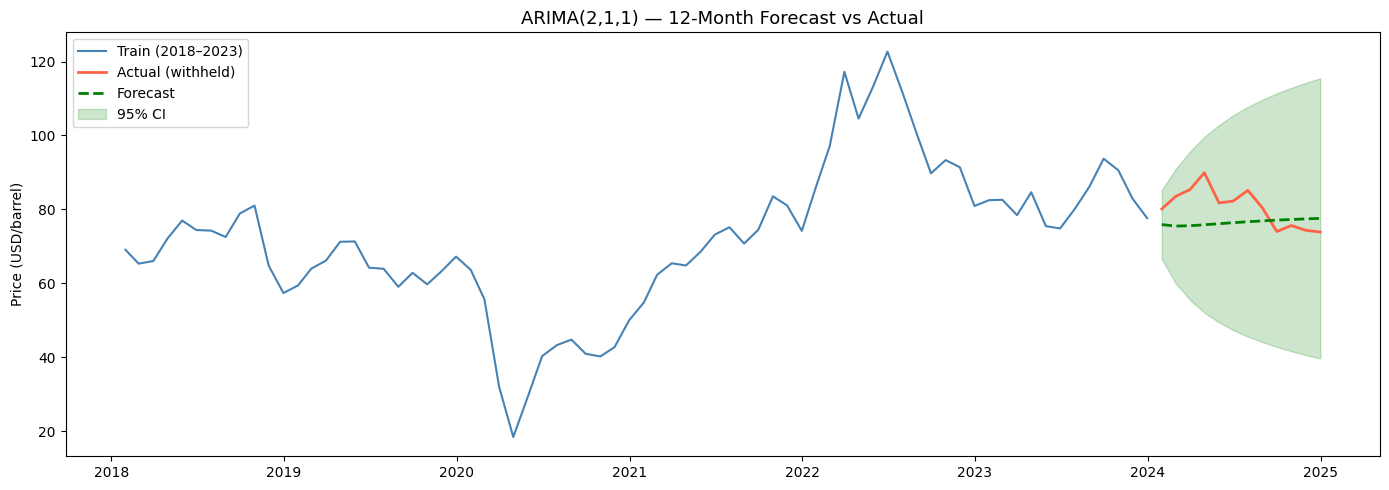

MAE  : 5.92
RMSE : 6.85
MAPE : 7.15%

                   Actual  Forecast  Error
observation_date                         
2024-01            80.12     75.88   4.24
2024-02            83.48     75.48   7.99
2024-03            85.41     75.58   9.83
2024-04            89.94     75.83  14.11
2024-05            81.75     76.12   5.63
2024-06            82.25     76.40   5.85
2024-07            85.15     76.66   8.50
2024-08            80.36     76.88   3.47
2024-09            74.02     77.09  -3.07
2024-10            75.63     77.26  -1.63
2024-11            74.35     77.42  -3.08
2024-12            73.86     77.56  -3.70


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Forecast next 12 steps
forecast      = model.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
conf_int      = forecast.conf_int()

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["price"]["2018":], color="steelblue", label="Train (2018–2023)")
ax.plot(test["price"], color="tomato", label="Actual (withheld)", linewidth=2)
ax.plot(forecast_mean.index, forecast_mean, color="green",
        linestyle="--", linewidth=2, label="Forecast")
ax.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                alpha=0.2, color="green", label="95% CI")
ax.set_title("ARIMA(2,1,1) — 12-Month Forecast vs Actual", fontsize=13)
ax.set_ylabel("Price (USD/barrel)")
ax.legend()
plt.tight_layout()
plt.savefig("forecast.png", dpi=150)
plt.show()

# Accuracy metrics
mae  = mean_absolute_error(test["price"], forecast_mean)
rmse = np.sqrt(mean_squared_error(test["price"], forecast_mean))
mape = np.mean(np.abs((test["price"].values - forecast_mean.values) / test["price"].values)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Actual vs Forecast table
comparison = pd.DataFrame({
    "Actual":   test["price"].values,
    "Forecast": forecast_mean.values,
    "Error":    test["price"].values - forecast_mean.values
}, index=test.index.strftime("%Y-%m"))
print("\n", comparison.round(2))

### 4.1 Forecast Results

| Metric | Value |
|--------|-------|
| MAE    | 5.92  |
| RMSE   | 6.85  |
| MAPE   | 7.15% |

The model successfully captured the general price level (~75–77 USD/barrel) throughout 2024. 
However, it underestimated the price spike in April 2024 (~$90/barrel), driven by escalating 
Middle East tensions — an event no statistical model could anticipate from historical patterns 
alone. The 95% confidence interval widened considerably over the forecast horizon, reflecting 
inherent uncertainty in long-range oil price prediction.

## 5. Discussion
This project applied the Box-Jenkins ARIMA methodology to forecast monthly Brent Crude Oil 
prices. The analysis confirmed that the series is non-stationary in levels but stationary 
after first differencing. ACF/PACF analysis and AIC-based model comparison identified 
ARIMA(2,1,1) as the best candidate model.

**Main conclusions:**
- Oil prices follow a non-stationary process with d=1
- ARIMA(2,1,1) provides a statistically adequate fit with white-noise residuals
- A 7.15% MAPE demonstrates reasonable forecasting accuracy for a volatile commodity

**Main problems encountered:**
- Heavy-tailed residuals due to extreme price shocks (2008 crash, 2020 COVID collapse) 
  violate the normality assumption
- ARIMA forecasts quickly revert to a flat mean for longer horizons, limiting usefulness 
  beyond 3–6 months
- Volatility clustering in residuals suggests a GARCH model would be a natural extension 
  to better capture time-varying variance